# EvoNex Phase 1: Exploratory Data Analysis & Preprocessing

This notebook demonstrates the end-to-end preprocessing pipeline for TESS light curves.
It downloads sample data using `lightkurve`, visualizes raw attributes, applies our custom preprocessing engine to remove noise and detrend the data, and prepares it for machine learning classification.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
import preprocessing as pp

plt.style.use('seaborn-v0_8-darkgrid')

C:\projects\EvoNex\venv\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


## 1. Data Ingestion
Let's download a known exoplanet host star (WASP-126, TIC 25155310) to visualize a real planetary transit.

In [2]:
# Download light curve for TIC 25155310 (WASP-126)
print("Downloading Lightcurve from MAST archive...")
search_result = lk.search_lightcurve("TIC 25155310", sector=1, author="SPOC")
lc = search_result.download()
print(f"Downloaded: {lc}")

Downloaded:        time             flux      ...   pos_corr1      pos_corr2   
                    electron / s  ...      pix            pix      
------------------ -------------- ... -------------- --------------
1325.2966258808235  9.2627041e+03 ...  2.9971417e-02 -6.6027217e-02
1325.2980147804474  9.2711973e+03 ... -4.2239105e-04 -1.0025273e-01
 1325.299403680013  9.2906729e+03 ... -1.2138215e-03 -1.0391606e-01
1325.3007925795785  9.2628174e+03 ... -2.9799975e-03 -1.1566762e-01
1325.3021814792023  9.2777139e+03 ... -9.8572923e-03 -1.1535366e-01
 1325.303570378768  9.2604170e+03 ... -1.0768156e-02 -1.1588433e-01
1325.3049592783916  9.2684199e+03 ... -6.7567211e-03 -1.2002597e-01
1325.3063481780152  9.2672148e+03 ... -8.2860291e-03 -1.1578123e-01
 1325.307737077639  9.2526143e+03 ... -1.2014245e-02 -1.1912200e-01
               ...            ... ...            ...            ...
1353.1648095155513  9.2582285e+03 ... -1.6124731e-02 -5.4954281e-03
1353.1661984014393  9.2979814e+03 ..

## 2. Raw Data Visualization
We visualize the raw `SAP_FLUX` (Simple Aperture Photometry) and `PDCSAP_FLUX` (Pre-search Data Conditioning SAP Flux). Note how PDCSAP is much cleaner because NASA pipelines have removed instrumental systematics.

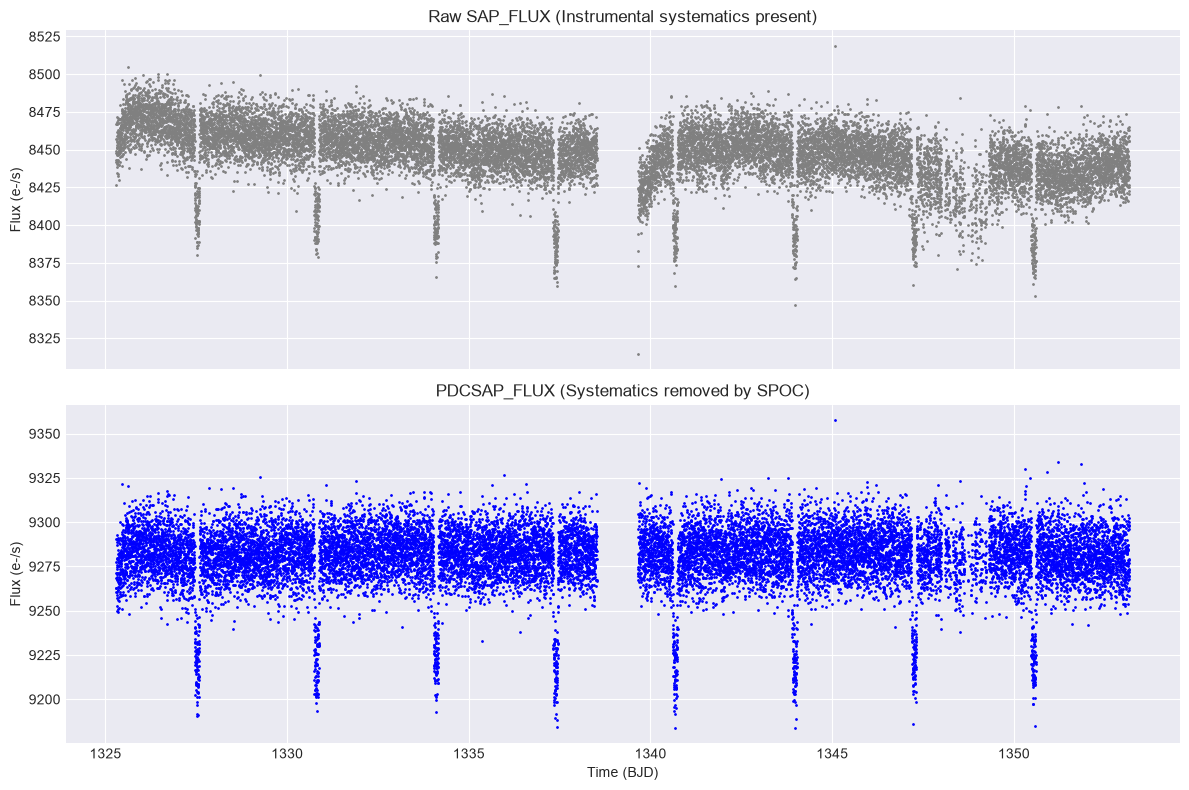

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Raw SAP Flux
ax[0].plot(lc.time.value, lc.sap_flux.value, '.', markersize=2, color='gray')
ax[0].set_title("Raw SAP_FLUX (Instrumental systematics present)")
ax[0].set_ylabel("Flux (e-/s)")

# PDCSAP Flux
ax[1].plot(lc.time.value, lc.pdcsap_flux.value, '.', markersize=2, color='blue')
ax[1].set_title("PDCSAP_FLUX (Systematics removed by SPOC)")
ax[1].set_ylabel("Flux (e-/s)")
ax[1].set_xlabel("Time (BJD)")

plt.tight_layout()
plt.show()

## 3. End-to-End Preprocessing Engine
Using our `preprocessing.py` module, we apply:
1. Quality Masking (removing bad cadences)
2. Median Normalization
3. Savitzky-Golay Detrending (removing low-frequency stellar variation)
4. Sigma Clipping (removing high-frequency outliers like cosmic rays)

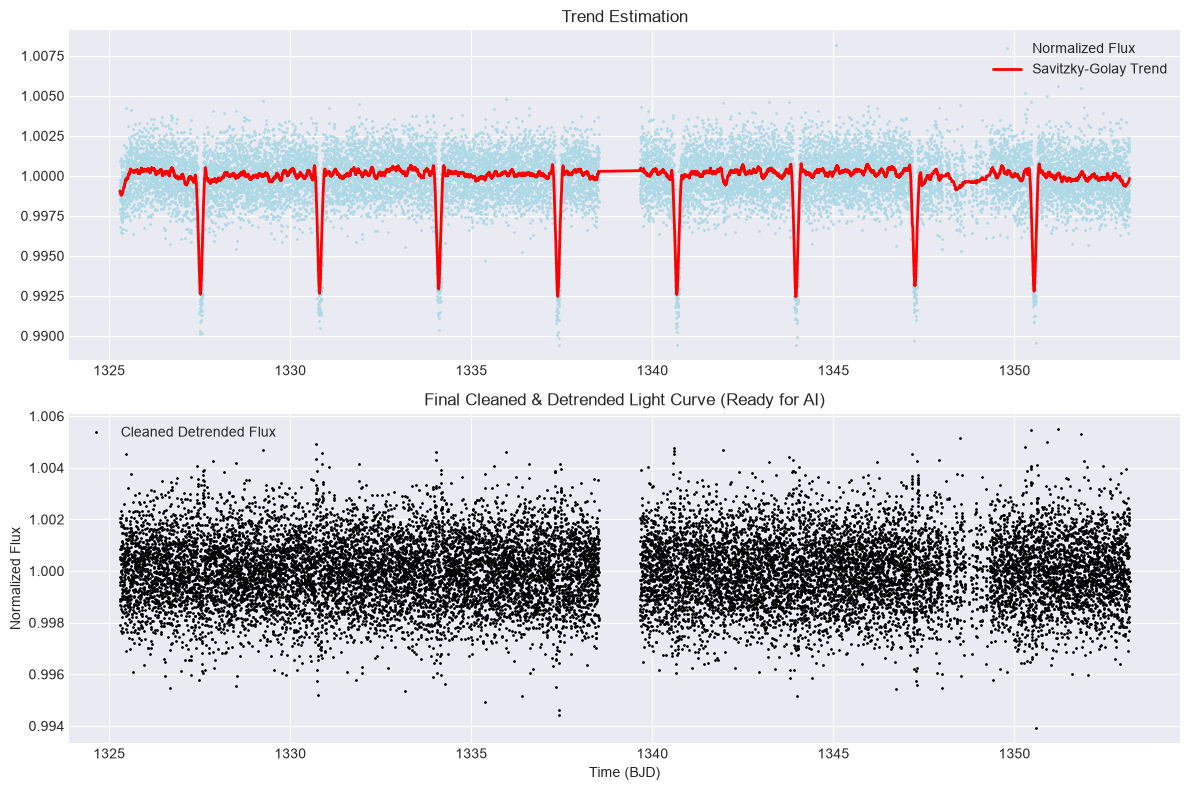

In [4]:
# Apply our preprocessing pipeline
processed_data = pp.process_lightcurve(lc)
time_clean = processed_data['time']
flux_clean = processed_data['flux']
trend = processed_data['trend']

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# Normalization and Trend fitting
raw_flux_norm = pp.normalize_flux(lc.remove_nans().pdcsap_flux.value)
ax[0].plot(lc.remove_nans().time.value, raw_flux_norm, '.', markersize=2, color='lightblue', label='Normalized Flux')
ax[0].plot(lc.remove_nans().time.value, trend, '-', color='red', linewidth=2, label='Savitzky-Golay Trend')
ax[0].set_title("Trend Estimation")
ax[0].legend()

# Final Cleaned and Detrended Data
ax[1].plot(time_clean, flux_clean, '.', markersize=2, color='black', label='Cleaned Detrended Flux')
ax[1].set_title("Final Cleaned & Detrended Light Curve (Ready for AI)")
ax[1].set_xlabel("Time (BJD)")
ax[1].set_ylabel("Normalized Flux")
ax[1].legend()

plt.tight_layout()
plt.show()

## 4. Phase Folding (Transit Visualization)
For WASP-126 b, the known orbital period is ~3.288 days. Let's fold the light curve at this period to see the transit dip clearly.

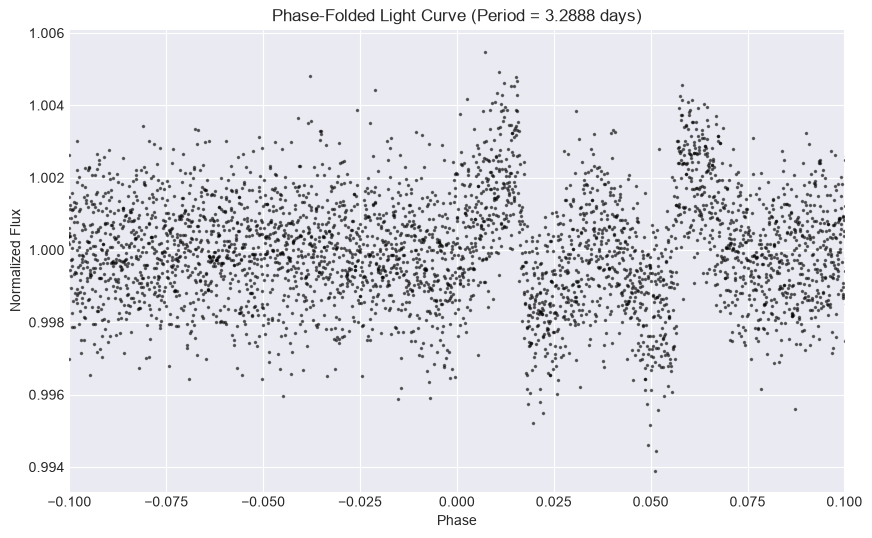

In [5]:
period = 3.2888
epoch = 1327.4  # Approximate epoch in BJD for Sector 1

# Calculate phase
phase = ((time_clean - epoch) % period) / period
# Shift phase to center transit at 0.5
phase[phase > 0.5] -= 1.0

plt.figure(figsize=(10, 6))
plt.plot(phase, flux_clean, '.', markersize=3, color='black', alpha=0.5)
plt.title(f"Phase-Folded Light Curve (Period = {period} days)")
plt.xlabel("Phase")
plt.ylabel("Normalized Flux")
plt.xlim(-0.1, 0.1) # Zoom in on the transit
plt.grid(True)
plt.show()